# Feature Engineering

This notebook documents the complete feature engineering pipeline that
transforms the EDA-ready dataset into model-ready train/test splits.
Key improvements over the initial pipeline include deduplication, BYD removal,
EV specs recovery, target encoding for high-cardinality features, and
hybrid one-hot/target encoding strategy.


In [1]:
import io, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".")
sys.path.insert(0, str(ROOT))

from src.viz.style import (
    apply_style, latex_safe, PALETTE,
    COLOR_PRIMARY, COLOR_ACCENT, COLOR_GOOD, COLOR_BAD,
    FIGSIZE_SINGLE, FIGSIZE_WIDE,
)

apply_style()

INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
REPORT_FE = ROOT / "reports" / "feature_engineering"
REPORT_FE.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(f"Project root: {ROOT}")
print(f"Report dir:   {REPORT_FE}")

Project root: C:\Users\dduya\Work\project\ev_car
Report dir:   C:\Users\dduya\Work\project\ev_car\reports\feature_engineering


## 1. Data Loading

Load the EDA-ready dataset which has been harmonized from 4 Vietnamese EV
marketplace websites and processed through LLM extraction and rule-based
cleaning.


In [2]:
df_raw = pd.read_csv(INTERIM / "ev_eda_ready.csv")
print(f"Loaded: {df_raw.shape[0]:,} records x {df_raw.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df_raw.dtypes.to_string())
print(f"\nMissing values:")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())


Loaded: 3,974 records x 19 columns

Column dtypes:
id                        int64
brand                       str
base_model                  str
model_mode                  str
year                    float64
condition                   str
mileage_km              float64
has_aftermarket_mods       bool
body_type                   str
seats                   float64
doors                   float64
drivetrain                  str
origin                      str
exterior_color              str
city                        str
seller_name                 str
post_date                   str
website                     str
price_vnd               float64

Missing values:
brand              27
year               67
condition         462
mileage_km        268
exterior_color    192
price_vnd           2


## 2. Deduplication Analysis

The raw dataset contains a significant number of exact duplicates across
multiple listing attributes. These duplicates cause the model to memorize
repeated entries rather than learning generalizable price patterns.


In [3]:
# Drop null prices first
df = df_raw.dropna(subset=["price_vnd"]).copy()

# Fix chotot.com 10x price inflation
if "website" in df.columns:
    chotot_mask = df["website"] == "chotot.com"
    n_chotot = chotot_mask.sum()
    df.loc[chotot_mask, "price_vnd"] = df.loc[chotot_mask, "price_vnd"] / 10
    print(f"Fixed chotot.com prices (/10): {n_chotot:,} records")

# Identify duplicates
dedup_cols = ["brand", "base_model", "model_mode", "year", "price_vnd", "condition", "mileage_km"]
n_before = len(df)
dup_mask = df.duplicated(subset=dedup_cols, keep="first")
n_dups = dup_mask.sum()
dup_pct = n_dups / n_before * 100

print(f"\nTotal records:     {n_before:,}")
print(f"Duplicate records: {n_dups:,} ({dup_pct:.1f}%)")
print(f"Unique records:    {n_before - n_dups:,}")

# Show most duplicated entries
dup_counts = df.groupby(dedup_cols).size().reset_index(name="count")
dup_counts = dup_counts[dup_counts["count"] > 1].sort_values("count", ascending=False)
print(f"\nTop 10 most duplicated entries:")
print(dup_counts.head(10).to_string(index=False))


Fixed chotot.com prices (/10): 1,644 records

Total records:     3,972
Duplicate records: 883 (22.2%)
Unique records:    3,089

Top 10 most duplicated entries:
  brand base_model model_mode     year        price_vnd condition  mileage_km  count
VinFast        VF9        VF9 2,025.00 1,229,000,000.00       New        0.00     23
VinFast        VF6        VF6 2,025.00   632,000,000.00       New        0.00     18
VinFast        VF5        VF5 2,025.00   482,000,000.00       New        0.00     16
VinFast        VF7        VF7 2,025.00   721,000,000.00       New        0.00     15
VinFast        VF3        VF3 2,025.00   299,000,000.00       New        0.00     14
VinFast        VF6   VF6 Plus 2,026.00   680,000,000.00       New        0.00     12
VinFast        VF5   VF5 Plus 2,025.00   485,000,000.00       New        0.00     11
VinFast        VF5   VF5 Plus 2,025.00   495,000,000.00       New        0.00     11
VinFast        VF5   VF5 Plus 2,026.00   430,000,000.00       New        0.

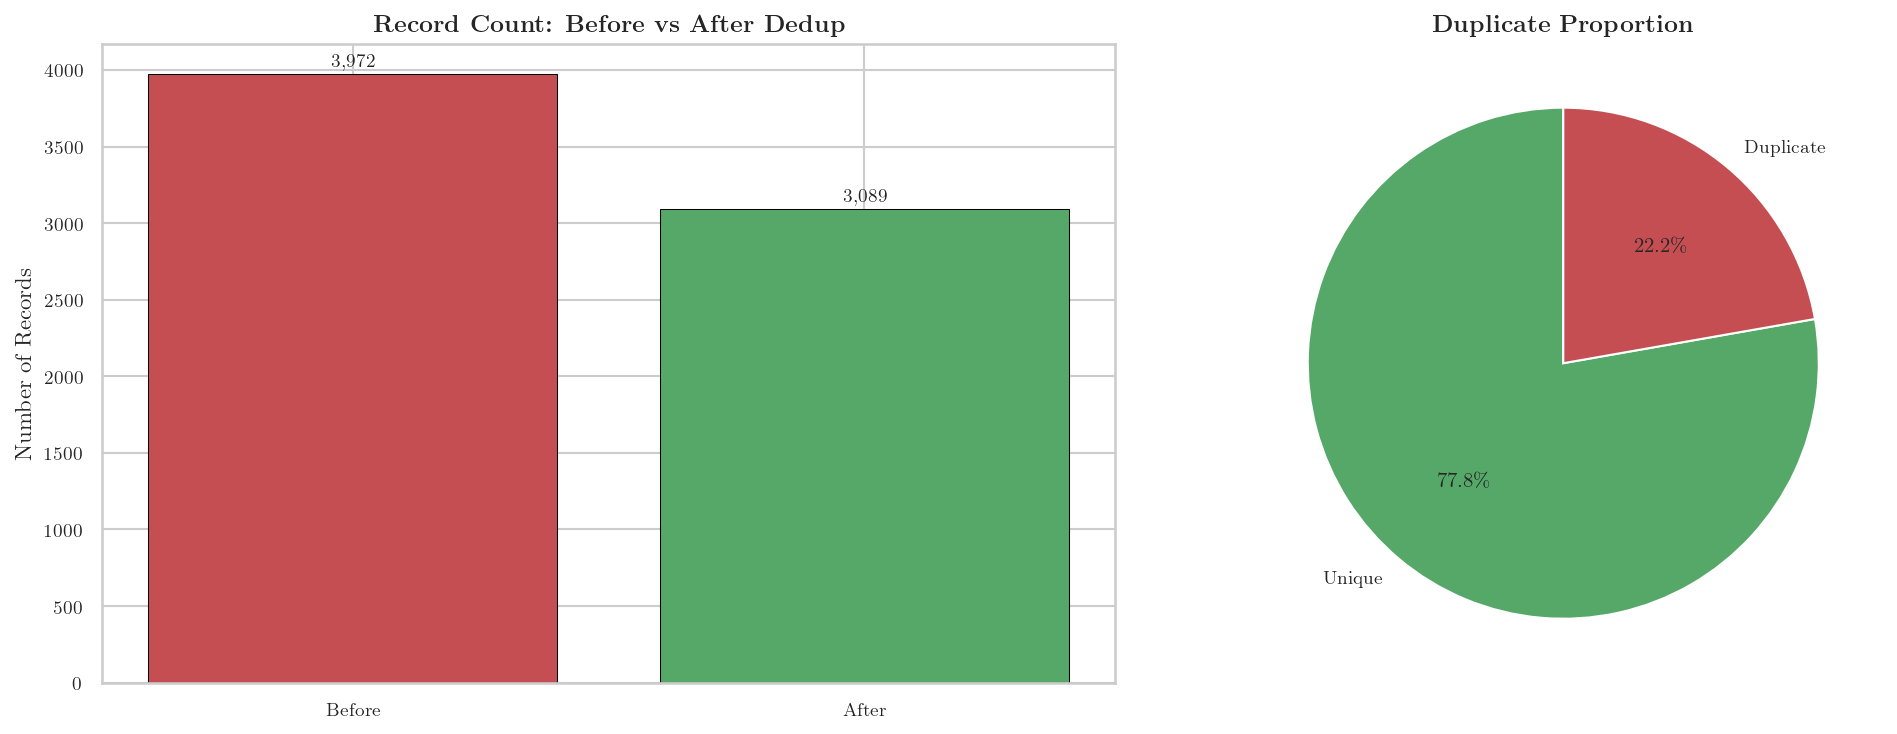

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\dedup_analysis.pdf


In [4]:
# Visualize dedup impact
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Bar chart: before vs after
labels = ["Before", "After"]
values = [n_before, n_before - n_dups]
colors = [COLOR_BAD, COLOR_GOOD]
bars = axes[0].bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Number of Records")
axes[0].set_title(r"\textbf{Record Count: Before vs After Dedup}")

# Pie chart: unique vs duplicate
axes[1].pie([n_before - n_dups, n_dups],
            labels=["Unique", "Duplicate"],
            colors=[COLOR_GOOD, COLOR_BAD],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title(r"\textbf{Duplicate Proportion}")

plt.tight_layout()
plt.savefig(REPORT_FE / "dedup_analysis.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'dedup_analysis.pdf'}")

In [5]:
# Apply deduplication
df = df.drop_duplicates(subset=dedup_cols, keep="first")
print(f"After dedup: {len(df):,} records")


After dedup: 3,089 records


## 3. BYD Systematic Price Error

All BYD records in the dataset exhibit approximately 10x inflated prices
compared to actual market values. This is a systematic error from the
scraping/extraction pipeline. Despite being only $\sim$2.3\% of data,
BYD contributes $\sim$14.5\% of total prediction error.


In [6]:
# BYD price analysis
byd = df[df["brand"] == "BYD"]
non_byd = df[df["brand"] != "BYD"]

print(f"BYD records: {len(byd):,} ({len(byd) / len(df) * 100:.1f}%)")
print(f"Non-BYD records: {len(non_byd):,}")
print(f"\nBYD price stats (VND):")
print(f"  Mean:   {byd['price_vnd'].mean():,.0f}")
print(f"  Median: {byd['price_vnd'].median():,.0f}")
print(f"  Min:    {byd['price_vnd'].min():,.0f}")
print(f"  Max:    {byd['price_vnd'].max():,.0f}")
print(f"\nNon-BYD price stats (VND):")
print(f"  Mean:   {non_byd['price_vnd'].mean():,.0f}")
print(f"  Median: {non_byd['price_vnd'].median():,.0f}")

# Show BYD base_model breakdown
print(f"\nBYD by base_model:")
print(byd.groupby("base_model")["price_vnd"].agg(["count", "mean", "median"]).to_string())


BYD records: 74 (2.4%)
Non-BYD records: 3,015

BYD price stats (VND):
  Mean:   824,108,108
  Median: 748,000,000
  Min:    66,000,000
  Max:    2,388,000,000

Non-BYD price stats (VND):
  Mean:   681,076,170
  Median: 640,000,000

BYD by base_model:
             count             mean           median
base_model                                          
Atto 2           7   571,571,428.57   669,000,000.00
Atto 3          12   627,333,333.33   670,000,000.00
Atto3 2025       1   590,000,000.00   590,000,000.00
Dolphin          6   495,166,666.67   489,500,000.00
Han              4 1,416,750,000.00 1,489,000,000.00
M6              17   706,411,764.71   695,000,000.00
M9               1 1,999,000,000.00 1,999,000,000.00
M9 Advance       1 1,999,000,000.00 1,999,000,000.00
M9 Advanced      1 2,388,000,000.00 2,388,000,000.00
Seal            13   939,923,076.92   950,000,000.00
Sealion 6        4   629,500,000.00   798,000,000.00
Sealion 8        4 1,377,000,000.00 1,359,500,000.00
VF MPV 

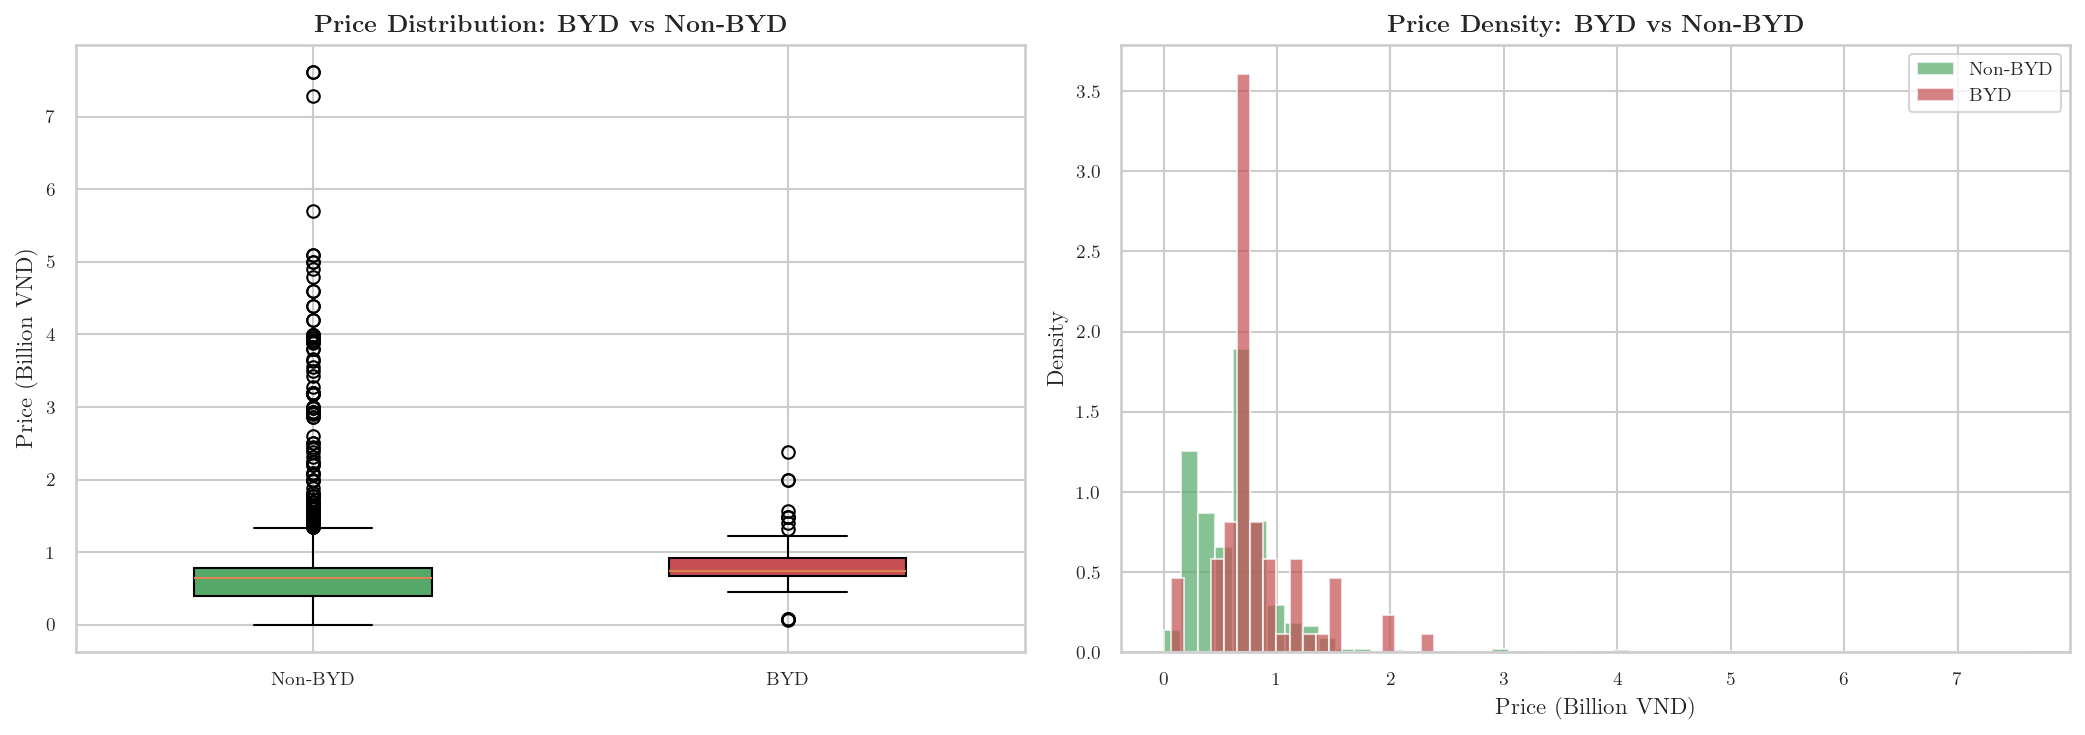

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\byd_removal.pdf


In [7]:
# Visualize BYD price anomaly
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Box plot: BYD vs non-BYD
data_box = [non_byd["price_vnd"] / 1e9, byd["price_vnd"] / 1e9]
bp = axes[0].boxplot(data_box, labels=["Non-BYD", "BYD"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor(COLOR_GOOD)
bp["boxes"][1].set_facecolor(COLOR_BAD)
axes[0].set_ylabel("Price (Billion VND)")
axes[0].set_title(r"\textbf{Price Distribution: BYD vs Non-BYD}")

# Histogram overlay
axes[1].hist(non_byd["price_vnd"] / 1e9, bins=50, alpha=0.7,
             label="Non-BYD", color=COLOR_GOOD, density=True)
axes[1].hist(byd["price_vnd"] / 1e9, bins=20, alpha=0.7,
             label="BYD", color=COLOR_BAD, density=True)
axes[1].set_xlabel("Price (Billion VND)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"\textbf{Price Density: BYD vs Non-BYD}")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_FE / "byd_removal.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'byd_removal.pdf'}")

In [8]:
# Remove BYD
n_byd = (df["brand"] == "BYD").sum()
df = df[df["brand"] != "BYD"]
print(f"Removed {n_byd} BYD records. Remaining: {len(df):,}")


Removed 74 BYD records. Remaining: 3,015


## 4. Missing Value Imputation

Apply targeted imputation strategies based on domain knowledge:
- **Brand**: lookup from `base\_model` (VinFast models are unambiguous)
- **Year**: median year per `base\_model`
- **Condition**: rule-based (mileage=0 + year$\geq$2025 $\to$ New)
- **Mileage**: 0 for New, median per brand for Used
- **Categoricals**: Vietnamese $\to$ English mapping


In [9]:
# Drop leakage columns
drop_cols = ["id", "seller_name", "post_date", "website"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Missing values BEFORE imputation:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0].to_string())
print(f"Total missing cells: {missing_before.sum()}")


Missing values BEFORE imputation:
brand              22
year               60
condition         386
mileage_km        196
exterior_color    119
Total missing cells: 783


In [10]:
# Brand imputation
if df["brand"].isna().any():
    brand_lookup = df.dropna(subset=["brand"]).groupby("base_model")["brand"].first().to_dict()
    df["brand"] = df["brand"].fillna(df["base_model"].map(brand_lookup))
    df["brand"] = df["brand"].fillna("Unknown")
    print(f"Brand NaN after imputation: {df['brand'].isna().sum()}")

# Year imputation
if df["year"].isna().any():
    year_median = df.groupby("base_model")["year"].transform("median")
    df["year"] = df["year"].fillna(year_median).fillna(df["year"].median())
    print(f"Year NaN after imputation: {df['year'].isna().sum()}")

# Condition imputation
if df["condition"].isna().any():
    mask_new = (df["mileage_km"].fillna(0) == 0) & (df["year"].fillna(0) >= 2025)
    df.loc[df["condition"].isna() & mask_new, "condition"] = "New"
    df.loc[df["condition"].isna(), "condition"] = "Used"
    print(f"Condition NaN after imputation: {df['condition'].isna().sum()}")

# Mileage imputation
if df["mileage_km"].isna().any():
    df.loc[(df["mileage_km"].isna()) & (df["condition"] == "New"), "mileage_km"] = 0
    mileage_med = df[df["condition"] == "Used"].groupby("brand")["mileage_km"].transform("median")
    used_mask = (df["mileage_km"].isna()) & (df["condition"] == "Used")
    df.loc[used_mask, "mileage_km"] = mileage_med
    df["mileage_km"] = df["mileage_km"].fillna(df["mileage_km"].median())
    print(f"Mileage NaN after imputation: {df['mileage_km'].isna().sum()}")

# Cap extreme mileage
df.loc[df["mileage_km"] > 300_000, "mileage_km"] = np.nan
df["mileage_km"] = df["mileage_km"].fillna(df["mileage_km"].median())

# Vietnamese -> English mappings
COLOR_MAP = {
    "Tr\u1eafng": "White", "\u0110\u1ecf": "Red", "\u0110en": "Black", "X\u00e1m": "Gray",
    "Xanh": "Blue", "Xanh l\u00e1": "Green", "Xanh d\u01b0\u01a1ng": "Blue",
    "V\u00e0ng": "Yellow", "B\u1ea1c": "Silver", "N\u00e2u": "Brown", "H\u1ed3ng": "Pink",
    "Cam": "Orange", "T\u00edm": "Purple", "Be": "Beige",
}
df["exterior_color"] = df["exterior_color"].map(COLOR_MAP).fillna("Other")

DRIVETRAIN_MAP = {
    "FWD - D\u1eabn \u0111\u1ed9ng c\u1ea7u tr\u01b0\u1edbc": "FWD", "C\u1ea7u tr\u01b0\u1edbc": "FWD",
    "C\u1ea7u Tr\u01b0\u1edbc": "FWD",
    "AWD - 4 b\u00e1nh to\u00e0n th\u1eddi gian": "AWD", "2 C\u1ea7u": "AWD",
    "4WD - D\u1eabn \u0111\u1ed9ng 4 b\u00e1nh": "AWD",
    "C\u1ea7u sau": "RWD", "RFD - D\u1eabn \u0111\u1ed9ng c\u1ea7u sau": "RWD",
    "C\u1ea7u Sau": "RWD", "RWD - D\u1eabn \u0111\u1ed9ng c\u1ea7u sau": "RWD",
}
df["drivetrain"] = df["drivetrain"].map(DRIVETRAIN_MAP).fillna("Other")

ORIGIN_MAP = {
    "Vi\u1ec7t Nam": "Domestic", "L\u1eafp r\u00e1p trong n\u01b0\u1edbc": "Domestic",
    "Nh\u1eadp kh\u1ea9u": "Imported", "N\u01b0\u1edbc kh\u00e1c": "Imported",
    "\u0110ang c\u1eadp nh\u1eadt": "Unknown",
}
df["origin"] = df["origin"].map(ORIGIN_MAP).fillna("Unknown")

CITY_MAP = {
    "H\u00e0 N\u1ed9i": "Hanoi", "H\u1ed3 Ch\u00ed Minh": "HCMC",
    "\u0110\u00e0 N\u1eb5ng": "DaNang",
    "H\u1ea3i Ph\u00f2ng": "HaiPhong", "C\u1ea7n Th\u01a1": "CanTho",
    "\u0110\u1ed3ng Nai": "DongNai",
}
df["city"] = df["city"].map(CITY_MAP).fillna("Other")

print("\nMissing values AFTER imputation:")
missing_after = df.isnull().sum()
remaining = missing_after[missing_after > 0]
if remaining.empty:
    print("All missing values resolved.")
else:
    print(remaining.to_string())


Brand NaN after imputation: 0
Year NaN after imputation: 0
Condition NaN after imputation: 0
Mileage NaN after imputation: 0

Missing values AFTER imputation:
All missing values resolved.


## 5. Derived Numeric Features

Create new features from existing columns:
- `car\_age`: $2026 - \text{year}$ (depreciation proxy)
- `is\_new`: binary indicator for new cars
- `log\_mileage`: $\log(1 + \text{mileage\_km})$ (reduces right skew)


In [11]:
df["car_age"] = 2026 - df["year"]
df["is_new"] = (df["condition"] == "New").astype(int)
df["log_mileage"] = np.log1p(df["mileage_km"])
df["has_aftermarket_mods"] = df["has_aftermarket_mods"].astype(int)

print("Derived features:")
print(f"  car_age:  min={df['car_age'].min():.0f}, max={df['car_age'].max():.0f}, median={df['car_age'].median():.0f}")
print(f"  is_new:   {df['is_new'].value_counts().to_dict()}")
print(f"  log_mileage: min={df['log_mileage'].min():.2f}, max={df['log_mileage'].max():.2f}")
print(f"  has_aftermarket_mods: {df['has_aftermarket_mods'].sum()} cars modified")


Derived features:
  car_age:  min=0, max=16, median=2
  is_new:   {0: 2096, 1: 919}
  log_mileage: min=0.00, max=12.52
  has_aftermarket_mods: 375 cars modified


## 6. EV Specifications Recovery

One of the most impactful improvements: recovering battery capacity (kWh),
driving range (km), and motor power (hp) from the otodien.vn raw data.
These are the most price-deterministic features for EVs --- a VF3 with
42~kWh/315M is fundamentally different from a VF9 with 123~kWh/1.5B.

A lookup table was built by extracting median specs per `base\_model` from
the otodien.vn dataset (729 records, 99.6\% fill rate).


In [12]:
# Load EV specs lookup
ev_specs = pd.read_csv(INTERIM / "ev_specs_lookup.csv")
print(f"EV specs lookup: {len(ev_specs)} models")
print(ev_specs.to_string(index=False))


EV specs lookup: 29 models
 base_model  battery_kwh  range_km  power_hp
     Atto 3        60.40    480.00    201.00
      BINGO        37.90    410.00     67.00
Bingo 333km        31.90    333.00     67.00
    Dolphin        44.90    405.00     94.00
   E34 xanh        42.00    318.60    147.00
     EC Van        17.00    150.00     41.00
Herio Green        37.20    326.00    136.00
 Limo Green        60.10    450.00    204.00
  Limogreen        60.10    450.00    204.00
         M6        55.40    420.00    161.00
   MERCEDES        66.50    422.00    190.00
Minio Green        14.70    170.00     27.00
   Mới 2025        37.20    326.40    134.00
NERIO GREEN        41.90    318.60    150.00
Nerio Green        41.90    318.60    150.00
       Seal        61.40    460.00    201.00
     Sẵn xe        59.60    399.00    134.00
       VF 3        18.60    210.00     43.00
     VF e34        42.00    318.60    147.00
        VF3        18.60    210.00     43.00
        VF5        37.20    

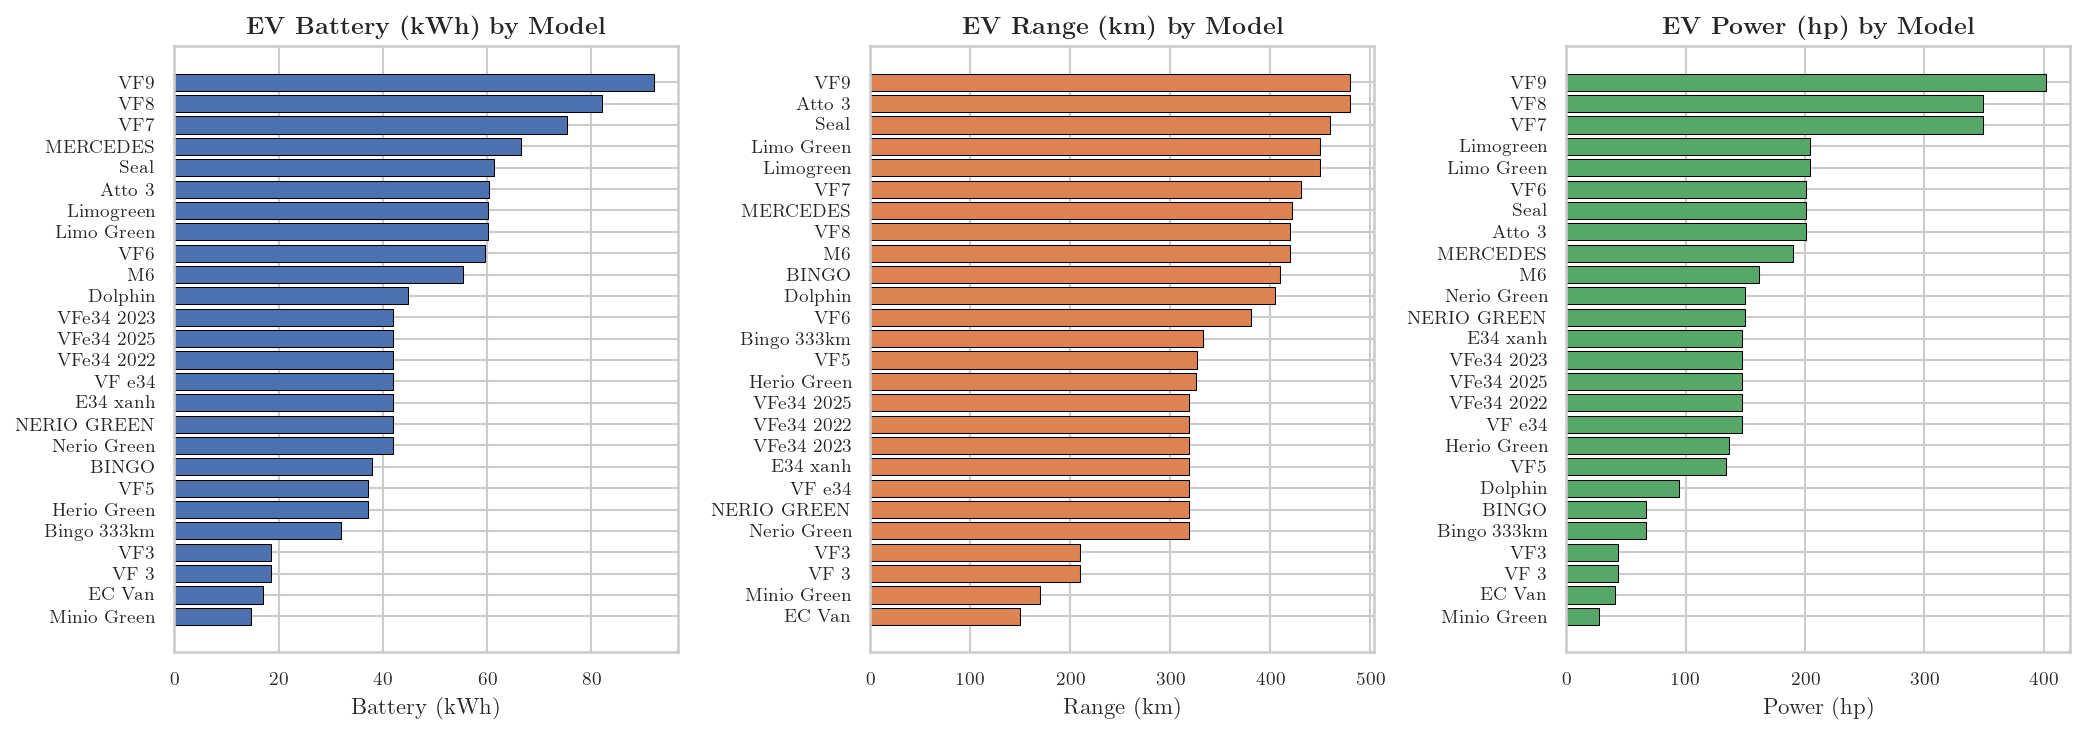

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\ev_specs_coverage.pdf


In [13]:
# Filter to known clean models only (remove Vietnamese/emoji entries)
import re

clean_mask = ev_specs["base_model"].apply(lambda x: bool(re.match(r'^[A-Za-z0-9 _\-]+$', x)))
ev_clean = ev_specs[clean_mask].copy()
# Escape underscores for LaTeX
ev_clean["label"] = ev_clean["base_model"].apply(latex_safe)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)

spec_cols = ["battery_kwh", "range_km", "power_hp"]
spec_titles = ["Battery (kWh)", "Range (km)", "Power (hp)"]

for ax, col, title, color in zip(axes, spec_cols, spec_titles, PALETTE[:3]):
    data = ev_clean.sort_values(col, ascending=True)
    ax.barh(data["label"], data[col], color=color, edgecolor="black", linewidth=0.5)
    ax.set_xlabel(title)
    ax.set_title(r"\textbf{EV " + title + r" by Model}")

plt.tight_layout()
plt.savefig(REPORT_FE / "ev_specs_coverage.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'ev_specs_coverage.pdf'}")

In [14]:
# Join EV specs
df = df.merge(ev_specs, on="base_model", how="left")
for col in ["battery_kwh", "range_km", "power_hp"]:
    fill_val = df[col].median()
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(fill_val)
    print(f"{col}: {n_missing} missing filled with median ({fill_val:.1f})")

print(f"\nEV spec correlations with price:")
for col in ["battery_kwh", "range_km", "power_hp"]:
    r = df[col].corr(df["price_vnd"])
    print(f"  {col}: r = {r:.4f}")


battery_kwh: 155 missing filled with median (59.6)
range_km: 155 missing filled with median (381.0)
power_hp: 155 missing filled with median (201.0)

EV spec correlations with price:
  battery_kwh: r = 0.4524
  range_km: r = 0.4578
  power_hp: r = 0.4149


## 7. Encoding Strategy

A critical design decision: **hybrid encoding** combining one-hot and
target encoding.

Why not target-encode everything?
An earlier attempt to target-encode all categoricals (brand, base\_model,
body\_type, etc.) caused R$^2$ to drop from 0.79 to 0.087. Root cause:
target-encoded features became nearly identical to the target itself,
especially for VinFast (93.6\% of data) where the encoded value was
$\sim$2.6B but actual prices range 50M--14B. The model became lazy,
relying solely on brand\_enc.

Solution:
- **Target encode** only high-cardinality features: model\_mode
      (324 unique, 0.76 correlation), model\_year (interaction feature)
- **One-hot encode** low-cardinality features: brand (5--8), base\_model
      ($\sim$15), body\_type (5), drivetrain (3), origin (3)
- **Drop** remaining categoricals: exterior\_color, city, brand\_body
      (low signal after EV specs added)


In [15]:
# Interaction features for target encoding
df["brand_body"] = df["brand"] + "_" + df["body_type"]
df["model_year"] = df["base_model"] + "_" + df["year"].astype(int).astype(str)

print(f"model_mode unique: {df['model_mode'].nunique()}")
print(f"model_year unique: {df['model_year'].nunique()}")
print(f"brand_body unique: {df['brand_body'].nunique()}")

# Show model_mode price variation (why it's valuable)
mm_stats = df.groupby("model_mode")["price_vnd"].agg(["count", "mean", "std"])
mm_stats = mm_stats[mm_stats["count"] >= 5].sort_values("mean", ascending=False)
# Filter to ASCII-only model_mode names for display
import re as _re

ascii_mask = [bool(_re.match(r'^[A-Za-z0-9 _\-\+/]+$', str(idx))) for idx in mm_stats.index]
mm_stats = mm_stats[ascii_mask]
print(f"\nTop 15 model_mode by price (min 5 records, ASCII names only):")
mm_stats["mean"] = mm_stats["mean"] / 1e9
mm_stats["std"] = mm_stats["std"] / 1e9
print(mm_stats.head(15).to_string())


model_mode unique: 295
model_year unique: 103
brand_body unique: 29

Top 15 model_mode by price (min 5 records, ASCII names only):
                 count  mean  std
model_mode                       
Taycan Base          9  3.89 0.15
EQS 580 4Matic       9  3.45 0.55
EQS 450 Plus         7  3.22 0.50
EQB 250              5  1.90 0.09
VF9 Plus 6S         11  1.33 0.24
VF9 Plus 7S         32  1.32 0.16
VF9                 47  1.21 0.19
VF9 Plus           132  1.19 0.18
VF9 Eco             23  1.18 0.16
VF9 2023 Plus        6  1.00 0.09
VF9 Plus 6S SDI      7  0.92 0.07
VF8 Lux Plus         6  0.91 0.07
VF8 Plus            88  0.85 0.14
VF7 Plus AWD        21  0.83 0.07
VF7 Plus            61  0.81 0.11


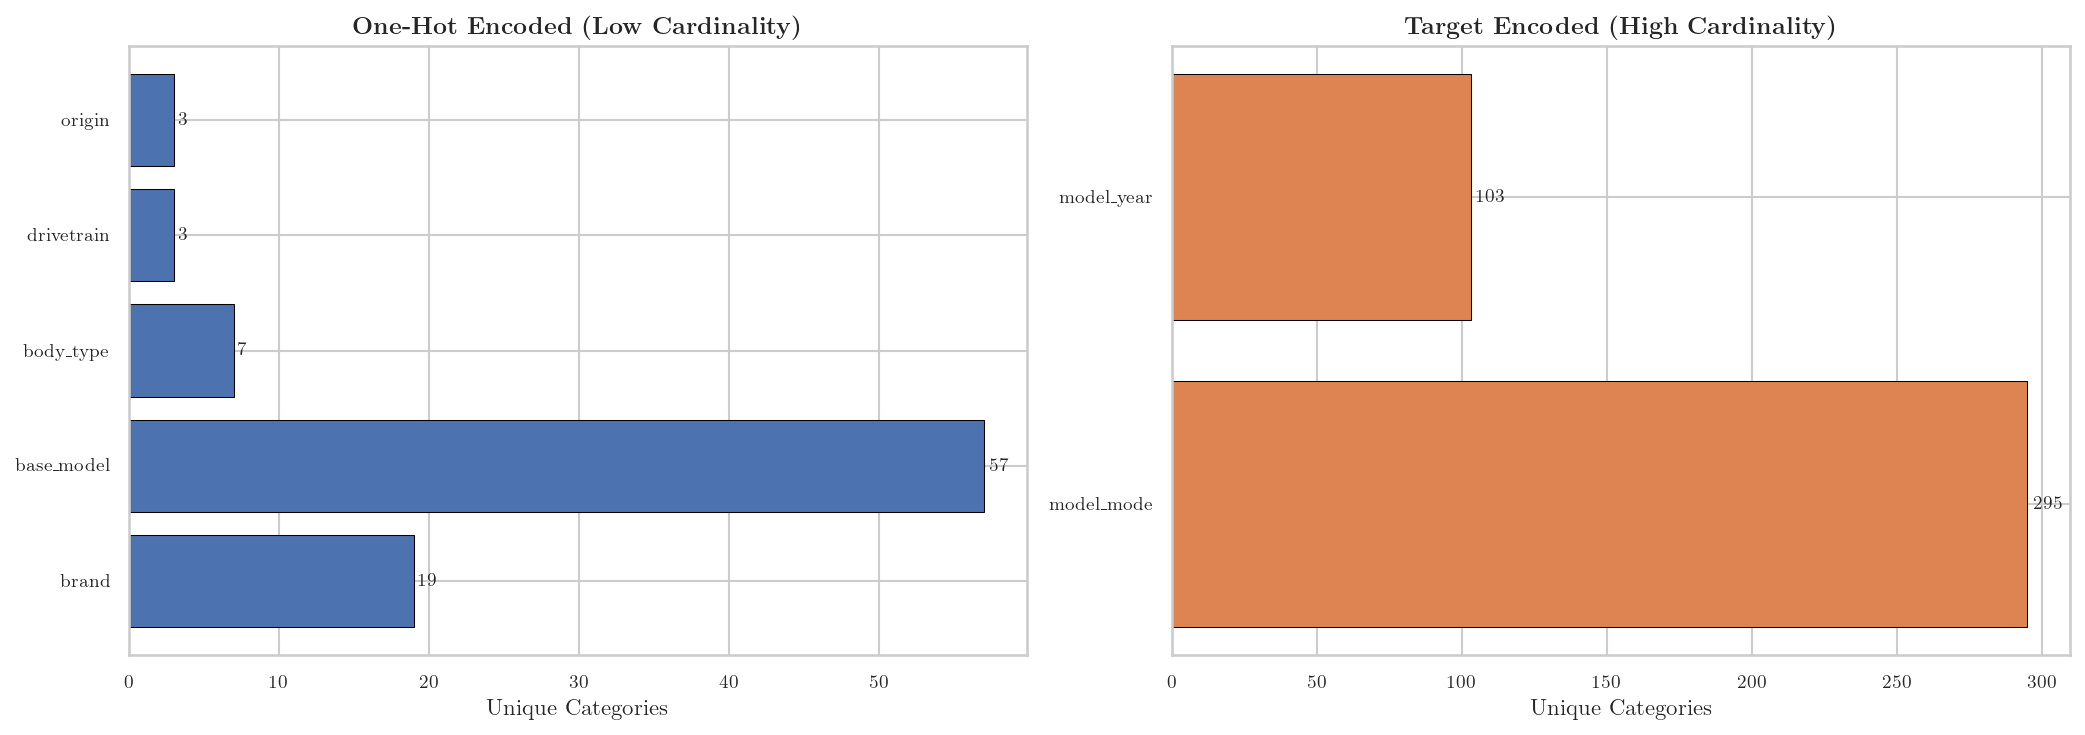

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\encoding_comparison.pdf


In [16]:
# Visualize encoding comparison
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Left: one-hot strategy
onehot_cats = {"brand": df["brand"].nunique(), "base_model": df["base_model"].nunique(),
               "body_type": df["body_type"].nunique(), "drivetrain": df["drivetrain"].nunique(),
               "origin": df["origin"].nunique()}
target_cats = {"model_mode": df["model_mode"].nunique(), "model_year": df["model_year"].nunique()}

cats_oh = [latex_safe(c) for c in onehot_cats.keys()]
vals_oh = list(onehot_cats.values())
axes[0].barh(cats_oh, vals_oh, color=COLOR_PRIMARY, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Unique Categories")
axes[0].set_title(r"\textbf{One-Hot Encoded (Low Cardinality)}")
for i, v in enumerate(vals_oh):
    axes[0].text(v + 0.3, i, str(v), va="center", fontsize=9)

cats_te = [latex_safe(c) for c in target_cats.keys()]
vals_te = list(target_cats.values())
axes[1].barh(cats_te, vals_te, color=COLOR_ACCENT, edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Unique Categories")
axes[1].set_title(r"\textbf{Target Encoded (High Cardinality)}")
for i, v in enumerate(vals_te):
    axes[1].text(v + 2, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORT_FE / "encoding_comparison.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'encoding_comparison.pdf'}")

## 8. Train/Test Split \& Feature Encoding

Split 80/20 stratified on `base\_model` (more meaningful than brand since
93.6\% is VinFast). Then apply target encoding on train set only (with
leave-one-out to prevent leakage) and transform test set.


In [17]:
from sklearn.model_selection import train_test_split
from src.features.target_encoder import TargetEncoder

# Drop non-feature columns
drop_cols = ["condition", "year", "mileage_km", "seats", "doors"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Separate target
target = df["price_vnd"]
features = df.drop(columns=["price_vnd"])

# Stratify on base_model
strat = features["base_model"].copy()
rare_mask = strat.map(strat.value_counts()) < 5
strat[rare_mask] = "_rare_"

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=strat
)
print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")

# --- Target encode high-cardinality ---
target_enc_cols = ["model_mode", "model_year"]
for col in target_enc_cols:
    if col not in X_train.columns:
        continue
    enc = TargetEncoder(smoothing=10)
    X_train[f"{col}_enc"] = enc.fit_transform_loo(X_train[col], y_train)
    X_test[f"{col}_enc"] = enc.transform(X_test[col])
    X_train = X_train.drop(columns=[col])
    X_test = X_test.drop(columns=[col])
    print(f"Target-encoded {col} -> {col}_enc (train mean: {X_train[f'{col}_enc'].mean() / 1e9:.3f}B)")

# --- One-hot encode low-cardinality ---
onehot_cols = ["brand", "base_model", "body_type", "drivetrain", "origin"]
for col in onehot_cols:
    if col not in X_train.columns:
        continue
    counts = X_train[col].value_counts()
    rare = counts[counts < 10].index
    X_train[col] = X_train[col].where(~X_train[col].isin(rare), "Other")
    X_test[col] = X_test[col].where(~X_test[col].isin(rare), "Other")
    known_cats = set(X_train[col].unique())
    X_test[col] = X_test[col].where(X_test[col].isin(known_cats), "Other")

X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=False, dtype=int)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=False, dtype=int)

# Align columns
for col in set(X_train.columns) - set(X_test.columns):
    X_test[col] = 0
for col in set(X_test.columns) - set(X_train.columns):
    X_train[col] = 0
X_test = X_test[X_train.columns]

# Drop remaining categoricals
drop_cats = ["exterior_color", "city", "brand_body"]
X_train = X_train.drop(columns=[c for c in drop_cats if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_cats if c in X_test.columns])

# Ensure all numeric
non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric: {non_numeric}")
    X_train = X_train.drop(columns=non_numeric)
    X_test = X_test.drop(columns=non_numeric)

# Fill NaN
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print(f"\nFinal features: {X_train.shape[1]}")
print(f"Feature names: {list(X_train.columns)}")


Train: 2,412 rows
Test:  603 rows
Target-encoded model_mode -> model_mode_enc (train mean: 0.628B)
Target-encoded model_year -> model_year_enc (train mean: 0.625B)

Final features: 41
Feature names: ['has_aftermarket_mods', 'car_age', 'is_new', 'log_mileage', 'battery_kwh', 'range_km', 'power_hp', 'model_mode_enc', 'model_year_enc', 'brand_Mercedes-Benz', 'brand_Other', 'brand_Porsche', 'brand_VinFast', 'brand_Wuling', 'base_model_EC Van', 'base_model_Herio Green', 'base_model_Limo', 'base_model_Limo Green', 'base_model_Minio Green', 'base_model_Other', 'base_model_Taycan', 'base_model_VF MPV 7', 'base_model_VF e34', 'base_model_VF3', 'base_model_VF5', 'base_model_VF6', 'base_model_VF7', 'base_model_VF8', 'base_model_VF9', 'body_type_Coupe', 'body_type_Hatchback', 'body_type_MPV', 'body_type_Other', 'body_type_SUV', 'body_type_Sedan', 'drivetrain_AWD', 'drivetrain_FWD', 'drivetrain_RWD', 'origin_Domestic', 'origin_Imported', 'origin_Unknown']


## 9. Feature Importance Analysis

Evaluate the engineered features using Pearson correlation with log-price
and mutual information scores.


In [18]:
from sklearn.feature_selection import mutual_info_regression

y_log = np.log1p(y_train)

# Pearson correlation with log_price
corr_with_target = X_train.corrwith(y_log).abs().sort_values(ascending=False)
print("Top 20 features by |Pearson correlation| with log_price:")
print(corr_with_target.head(20).apply(lambda x: f"{x:.4f}").to_string())

# Mutual information
mi_scores = mutual_info_regression(X_train, y_log, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({"Feature": X_train.columns, "MI_Score": mi_scores})
mi_df = mi_df.sort_values("MI_Score", ascending=False)
print(f"\nTop 20 features by mutual information:")
print(mi_df.head(20).to_string(index=False))


Top 20 features by |Pearson correlation| with log_price:
model_year_enc         0.7417
model_mode_enc         0.7212
battery_kwh            0.6891
range_km               0.6873
power_hp               0.6615
base_model_VF3         0.5577
drivetrain_RWD         0.5045
drivetrain_AWD         0.4440
body_type_Hatchback    0.4309
body_type_SUV          0.3727
base_model_VF9         0.3379
origin_Imported        0.3070
brand_VinFast          0.3054
base_model_VF8         0.2736
brand_Mercedes-Benz    0.2670
base_model_Other       0.2457
car_age                0.2096
brand_Porsche          0.2093
base_model_Taycan      0.1929
base_model_VF5         0.1907



Top 20 features by mutual information:
            Feature  MI_Score
     model_year_enc      2.19
     model_mode_enc      1.67
           range_km      1.27
        battery_kwh      1.26
           power_hp      1.24
     base_model_VF3      0.41
     drivetrain_RWD      0.39
        log_mileage      0.37
            car_age      0.31
     base_model_VF8      0.29
     drivetrain_AWD      0.28
     base_model_VF5      0.28
     drivetrain_FWD      0.27
     base_model_VF9      0.23
      body_type_SUV      0.20
             is_new      0.20
body_type_Hatchback      0.19
     base_model_VF6      0.16
      brand_VinFast      0.11
   base_model_Other      0.09


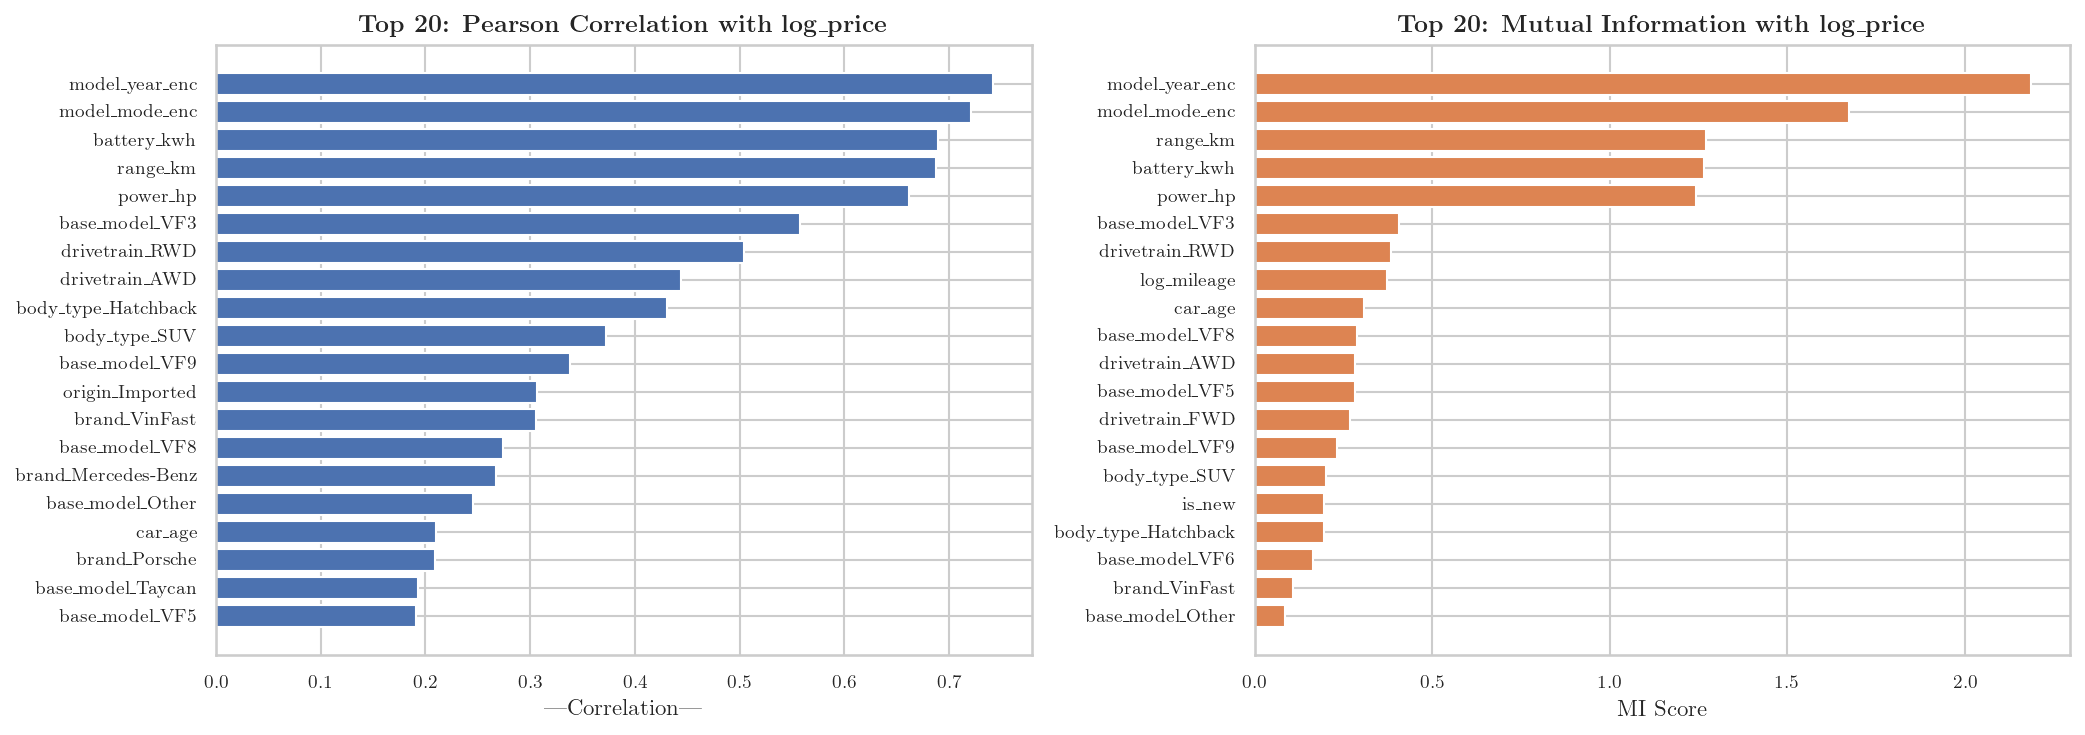

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\feature_importance_summary.pdf


In [19]:
# Feature importance plot
top_n = 20
corr_top = corr_with_target.head(top_n).reset_index()
corr_top.columns = ["Feature", "Correlation"]
mi_top = mi_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

axes[0].barh([latex_safe(f) for f in corr_top["Feature"][::-1]],
             corr_top["Correlation"][::-1].values, color=COLOR_PRIMARY)
axes[0].set_title(r"\textbf{Top 20: Pearson Correlation with log\_price}")
axes[0].set_xlabel("|Correlation|")

axes[1].barh([latex_safe(f) for f in mi_top["Feature"][::-1].values],
             mi_top["MI_Score"][::-1].values, color=COLOR_ACCENT)
axes[1].set_title(r"\textbf{Top 20: Mutual Information with log\_price}")
axes[1].set_xlabel("MI Score")

plt.tight_layout()
plt.savefig(REPORT_FE / "feature_importance_summary.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'feature_importance_summary.pdf'}")

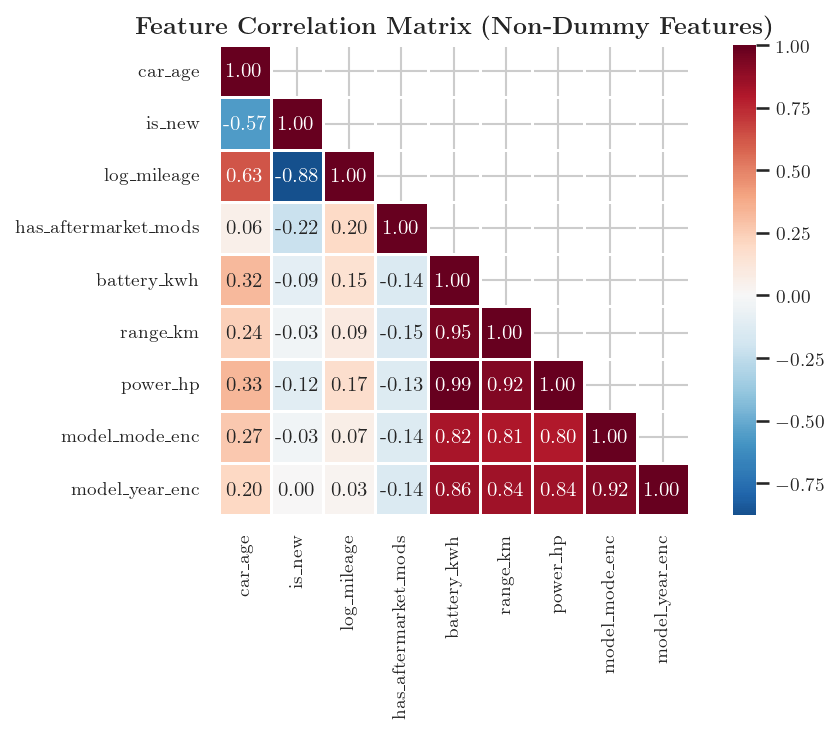

Saved: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering\feature_correlation_matrix.pdf


In [20]:
# Correlation matrix of numeric features (non-dummy)
numeric_feats = ["car_age", "is_new", "log_mileage", "has_aftermarket_mods",
                 "battery_kwh", "range_km", "power_hp",
                 "model_mode_enc", "model_year_enc"]
numeric_feats = [f for f in numeric_feats if f in X_train.columns]

corr_matrix = X_train[numeric_feats].corr()

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
safe_labels = [latex_safe(f) for f in numeric_feats]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, xticklabels=safe_labels, yticklabels=safe_labels,
            square=True, linewidths=0.5)
ax.set_title(r"\textbf{Feature Correlation Matrix (Non-Dummy Features)}")

plt.tight_layout()
plt.savefig(REPORT_FE / "feature_correlation_matrix.pdf", format="pdf")
plt.show()
print(f"Saved: {REPORT_FE / 'feature_correlation_matrix.pdf'}")

## 10. Save Outputs \& Summary

Save all model-ready datasets and the fitted scaler for downstream model
training and benchmarking.


In [21]:
from sklearn.preprocessing import StandardScaler
import joblib

PROCESSED.mkdir(parents=True, exist_ok=True)

# Scale for LR/SVR
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

# Log targets
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Sample weights
sw = np.ones(len(y_train))
sw = sw / sw.mean()

# Save all
X_train.to_csv(PROCESSED / "X_train.csv", index=False)
X_test.to_csv(PROCESSED / "X_test.csv", index=False)
X_train_scaled.to_csv(PROCESSED / "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(PROCESSED / "X_test_scaled.csv", index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False, header=["price_vnd"])
y_test.to_csv(PROCESSED / "y_test.csv", index=False, header=["price_vnd"])
y_train_log.to_csv(PROCESSED / "y_train_log.csv", index=False, header=["log_price_vnd"])
y_test_log.to_csv(PROCESSED / "y_test_log.csv", index=False, header=["log_price_vnd"])
pd.DataFrame({"feature": X_train.columns}).to_csv(PROCESSED / "feature_names.csv", index=False)
joblib.dump(scaler, PROCESSED / "scaler.joblib")
pd.DataFrame({"weight": sw}).to_csv(PROCESSED / "sample_weights_train.csv", index=False)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\nTrain: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"\nTarget (raw):  min={y_train.min():,.0f}, median={y_train.median():,.0f}, max={y_train.max():,.0f}")
print(f"Target (log):  skewness={y_train_log.skew():.4f}")
print(f"\nAll outputs saved to: {PROCESSED}")
for f in sorted(PROCESSED.iterdir()):
    print(f"  {f.name}: {f.stat().st_size:,} bytes")

print(f"\nPDF reports saved to: {REPORT_FE}")
for f in sorted(REPORT_FE.glob("*.pdf")):
    print(f"  {f.name}")


FEATURE ENGINEERING COMPLETE

Train: 2,412 samples x 41 features
Test:  603 samples x 41 features

Target (raw):  min=968,000, median=640,000,000, max=7,610,000,000
Target (log):  skewness=-1.5669

All outputs saved to: C:\Users\dduya\Work\project\ev_car\data\processed
  feature_names.csv: 684 bytes
  sample_weights_train.csv: 12,068 bytes
  scaler.joblib: 2,511 bytes
  X_test.csv: 84,741 bytes
  X_test_scaled.csv: 498,154 bytes
  X_train.csv: 337,539 bytes
  X_train_scaled.csv: 1,991,151 bytes
  y_test.csv: 7,917 bytes
  y_test_log.csv: 11,842 bytes
  y_train.csv: 31,575 bytes
  y_train_log.csv: 47,398 bytes

PDF reports saved to: C:\Users\dduya\Work\project\ev_car\reports\feature_engineering
  byd_removal.pdf
  dedup_analysis.pdf
  encoding_comparison.pdf
  ev_specs_coverage.pdf
  feature_correlation_matrix.pdf
  feature_importance_summary.pdf


## Model Readiness Table

| Model | Features file | Target file | Notes |
|---|---|---|---|
| Linear Regression | `X\_train\_scaled.csv` | `y\_train\_log.csv` | Log target, scaled features |
| SVR | `X\_train\_scaled.csv` | `y\_train\_log.csv` | Log target, scaled features |
| Random Forest | `X\_train.csv` | `y\_train.csv` | Raw target, unscaled features |
| XGBoost | `X\_train.csv` | `y\_train.csv` | Raw target, unscaled features |
